In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(X_train, y_train),(X_test, y_test)=datasets.cifar10.load_data()

In [3]:
X_test.shape

(10000, 32, 32, 3)

In [4]:
X_train.shape

(50000, 32, 32, 3)

In [5]:
y_train.shape

(50000, 1)

In [6]:
#its a 2D Array
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [7]:
#converting it in to a 2D Array
y_train=y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [8]:
classes=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

In [36]:
def plot_sample(X, y, index):
    plt.figure(figsize=(15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

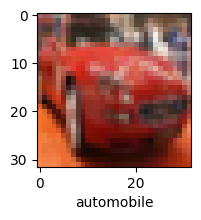

In [10]:
plot_sample(X_train, y_train, 5)

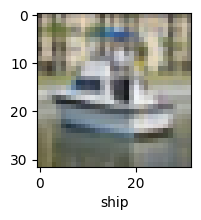

In [11]:
plot_sample(X_train, y_train, 501)

In [12]:
#normalizing the data
X_train=X_train / 255.0
X_test=X_test / 255.0

In [13]:
#building simple Neural network for image classification
ann=models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(3000, activation= 'relu'),
    layers.Dense(1000, activation= 'relu'),
    layers.Dense(10, activation= 'softmax'),
])

ann.compile(optimizer='SGD',
           loss='sparse_categorical_crossentropy',
           metrics=['accuracy'])

ann.fit(X_train, y_train, epochs=5)

D:\jn\TensorFlowProject\tfvenv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.3546 - loss: 1.8102
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.4266 - loss: 1.6220
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.4570 - loss: 1.5434
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.4797 - loss: 1.4796
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.4953 - loss: 1.4350


In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
y_pred=ann.predict(X_test)
y_pred_classes=[np.argmax(element) for element in y_pred]

print('classification report: \n', classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
classification report: 
               precision    recall  f1-score   support

           0       0.57      0.56      0.57      1000
           1       0.68      0.56      0.62      1000
           2       0.33      0.36      0.35      1000
           3       0.35      0.27      0.30      1000
           4       0.36      0.50      0.42      1000
           5       0.39      0.40      0.40      1000
           6       0.45      0.61      0.52      1000
           7       0.61      0.49      0.54      1000
           8       0.67      0.57      0.62      1000
           9       0.62      0.53      0.57      1000

    accuracy                           0.49     10000
   macro avg       0.50      0.49      0.49     10000
weighted avg       0.50      0.49      0.49     10000



<function matplotlib.pyplot.show(close=None, block=None)>

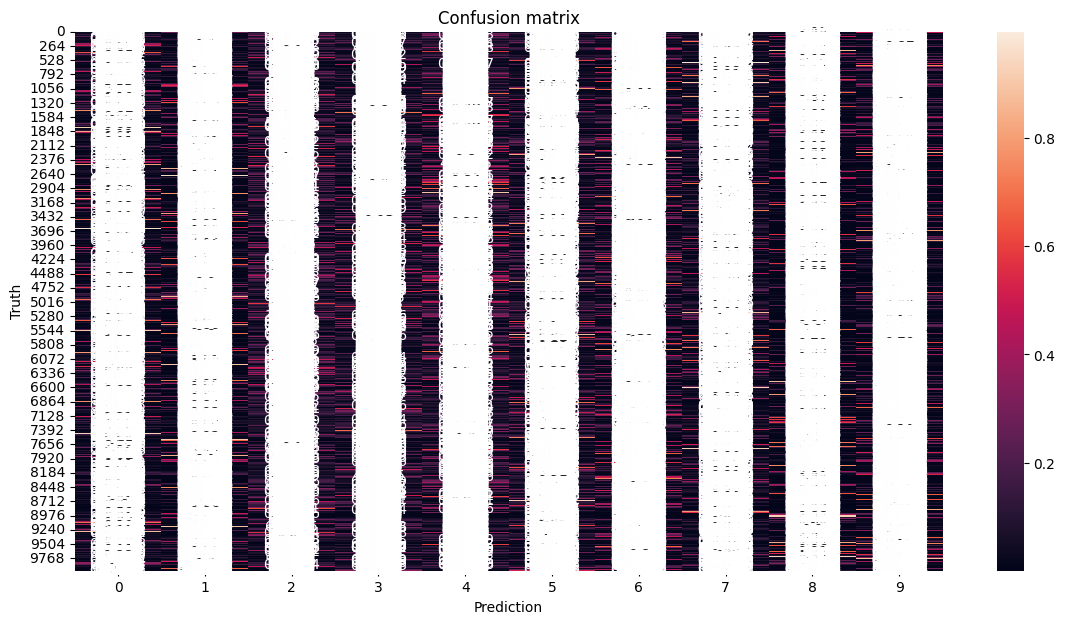

In [15]:
import seaborn as sns
plt.figure(figsize = (14,7))
sns.heatmap(y_pred, annot = True)
plt.ylabel('Truth')
plt.xlabel('Prediction')
plt.title('Confusion matrix')
plt.show

In [16]:
#making cnn model to train our images
cnn=models.Sequential([
   layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])



D:\jn\TensorFlowProject\tfvenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
cnn.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [18]:
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - accuracy: 0.4697 - loss: 1.4688
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.6087 - loss: 1.1189
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.6531 - loss: 0.9950
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.6819 - loss: 0.9144
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.7015 - loss: 0.8564
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.7220 - loss: 0.7977
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.7372 - loss: 0.7532
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.7530 - loss: 0.7097
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.7678 - loss: 0.6698
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.7797 - loss: 0.6320


In [19]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6886 - loss: 0.9609


[0.9608927965164185, 0.6886000037193298]

In [26]:
y_pred=cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


array([[5.57739186e-05, 2.67321884e-04, 1.91379245e-03, 9.64382052e-01,
        1.33493304e-05, 1.56538449e-02, 1.69460066e-02, 1.52278608e-05,
        2.87993636e-04, 4.64695157e-04],
       [2.24540461e-04, 9.18693841e-01, 3.25883235e-07, 7.77418752e-09,
        2.27350334e-08, 5.83627091e-10, 4.12932177e-09, 8.02331479e-10,
        8.09047818e-02, 1.76530128e-04],
       [1.34325936e-01, 5.59916139e-01, 7.43301352e-03, 4.09782073e-03,
        1.20544888e-03, 1.69749476e-03, 5.95035031e-04, 4.22436715e-04,
        1.02746725e-01, 1.87559873e-01],
       [7.61700273e-01, 4.43797819e-02, 3.77985276e-02, 3.71560035e-03,
        9.62802116e-03, 4.67889709e-04, 1.96894095e-03, 2.33811603e-04,
        1.39545292e-01, 5.61928144e-04],
       [8.82152563e-07, 2.36036567e-06, 1.71998292e-02, 4.74729156e-03,
        5.23206852e-02, 1.62497206e-04, 9.25559938e-01, 2.81007459e-07,
        5.85366570e-06, 3.16804005e-07]], dtype=float32)

In [27]:
y_classes=[np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(1), np.int64(1), np.int64(0), np.int64(6)]

In [33]:
y_test[:5]

array([[3],
       [8],
       [8],
       [0],
       [6]], dtype=uint8)

In [46]:
y_test = y_test.reshape(-1,)

In [47]:
def plot_sample(X, y, index):
    plt.figure(figsize=(15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

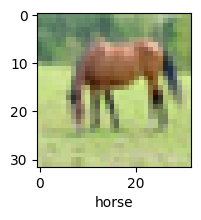

In [55]:
#here our model is predicting using test data 
#as you can see there picture of horse and and our model is predicting is correctly
plot_sample(X_test,y_test,60)

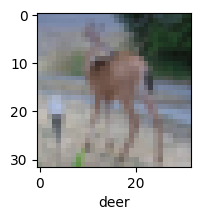

In [49]:
plot_sample(X_test, y_test, 100)

In [54]:
#here we checking is it predicting the right classes or not
classes[y_classes[60]]

'horse'